**Customer Churn Prediction**

**Step 1: Load Dataset**

In [1]:
import pandas as pd

df = pd.read_csv("../data/Telco-Customer-Churn.csv")

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [2]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


**STEP 2: Data Cleaning + EDA**

In [4]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

# Handle missing values
df.dropna(inplace=True)

# Drop unnecessary column
df.drop("customerID", axis=1, inplace=True)

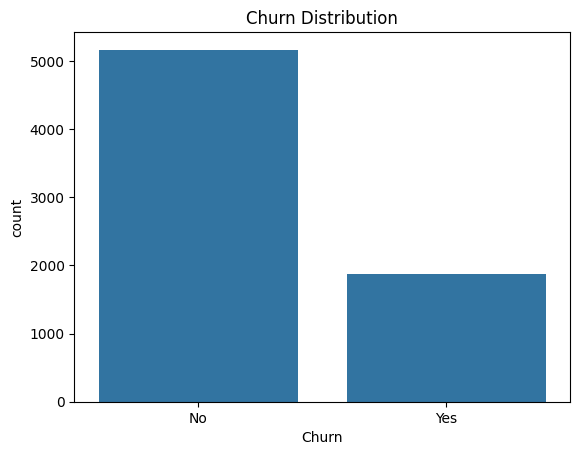

In [5]:
# Churn Distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")

plt.savefig("../outputs/plots/churn_distribution.png")
plt.show()

**STEP 3: Feature Engineering**

In [ ]:
# Encode Target
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# Encode Categorical Features
df = pd.get_dummies(df, drop_first=True)

In [ ]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_scaled = scaler.fit_transform(X)

**STEP 4: Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

**STEP 5: Handle Imbalance (SMOTE)**

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

**STEP 6: Model Training**

In [ ]:
# Logistic Regreesion
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test)

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)

**STEP 7: Evaluation**

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.73      0.75      1407

Random Forest:
               precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.59      0.58       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.78      0.78      1407



In [ ]:
# ROC_AUC Score
y_prob_rf = rf.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob_rf)
print("Random Forest ROC-AUC:", roc_auc)

Random Forest ROC-AUC: 0.8168863338699908


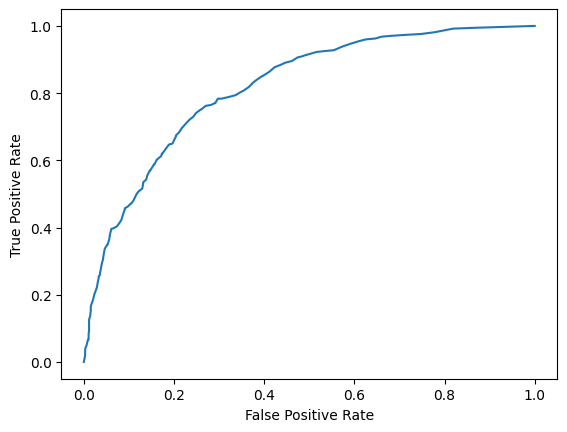

In [ ]:
# ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.savefig("../outputs/plots/roc_curve.png")
plt.show()

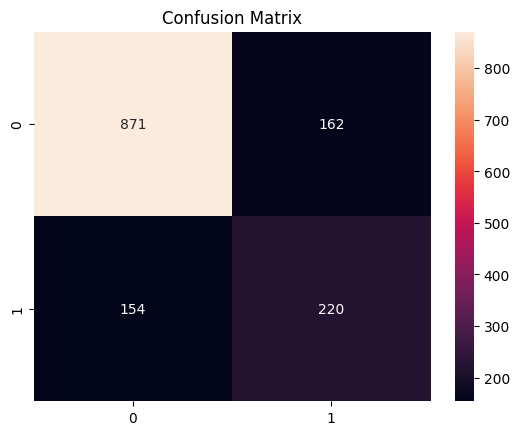

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")

plt.savefig("../outputs/plots/confusion_matrix.png")
plt.show()

**STEP 8: Feature Importance (Business Insight)**

In [ ]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))


tenure                            0.154285
TotalCharges                      0.139205
MonthlyCharges                    0.127245
Contract_Two year                 0.054387
OnlineSecurity_Yes                0.048330
InternetService_Fiber optic       0.046076
PaymentMethod_Electronic check    0.040937
TechSupport_Yes                   0.035604
Contract_One year                 0.035581
PaperlessBilling_Yes              0.032057
dtype: float64


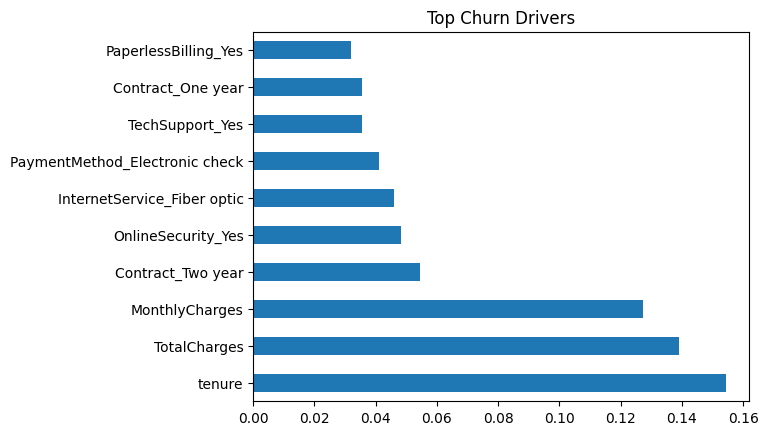

In [ ]:
# Plot 10 most important feature
feature_importance.head(10).plot(kind='barh')
plt.title("Top Churn Drivers")

plt.savefig("../outputs/plots/feature_importance.png")
plt.show()

**STEP 9: Save Outputs**

In [ ]:
import joblib

joblib.dump(rf, "outputs/customer_churn_model.pkl")
joblib.dump(scaler, "outputs/scaler.pkl")
joblib.dump(X.columns.tolist(), "outputs/features.pkl") 

['../outputs/features.pkl']